**Задача 1.15.** Полиномы Лежандра встречаются при решении задач математической физики в сферических координатах. Найти численно первые полиномы Лежандра как решение задачи на собственные функции:

\begin{equation*}
\begin{cases}
\frac{d}{dx} \left( (1 - x^2) \frac{du}{dx} \right) = -\lambda u(x), \quad -1 < x < 1, \\
\lim\limits_{x \to \pm 1} (1 - x^2)u'(x) = 0.
\end{cases}
\end{equation*}

In [ ]:
import numpy as np

import scipy.sparse as sp
import scipy.linalg as la
from scipy.sparse.linalg import eigsh, spsolve
from scipy.special import eval_legendre

import matplotlib.pyplot as plt

In [ ]:
N = 10000
h = 2.0 / N

xf = np.linspace(-1, 1, N + 1)
xc = xf[:-1] + h / 2.0
pf = 1.0 - xf**2

In [ ]:
d_main = (pf[:-1] + pf[1:]) / h**2
d_sub = -pf[1:-1] / h**2
d_sup = -pf[1:-1] / h**2

A_sparse = sp.diags([d_sub, d_main, d_sup], [-1, 0, 1], format='csc')

In [ ]:
def inverse_power_spsolve(A, shift, tol=1e-8, max_iters=1000):
    size = A.shape[0]

    M = A - shift * sp.eye(size, format='csc')

    np.random.seed(42)
    v = np.random.rand(size)
    v = v / np.linalg.norm(v)
    lambda_old = 0.0

    for _ in range(max_iters):
        w = spsolve(M, v)

        v = w / np.linalg.norm(w)
        lambda_new = np.dot(A @ v, v)
        if np.abs(lambda_new - lambda_old) < tol:
            break
        lambda_old = lambda_new

    return lambda_new, v

n  | Точное λ   | λ (spsolve)        | λ (eigsh)       | Погрешность функции 
--------------------------------------------------------------------------------
0  | 0          | -0.000000          | 0.000000        | 2.40e-06
1  | 2          | 2.000000           | 2.000000        | 1.00e-04
2  | 6          | 6.000000           | 6.000000        | 3.00e-04
3  | 12         | 12.000000          | 12.000000       | 6.00e-04
4  | 20         | 20.000000          | 20.000000       | 1.00e-03
5  | 30         | 30.000000          | 30.000000       | 1.50e-03


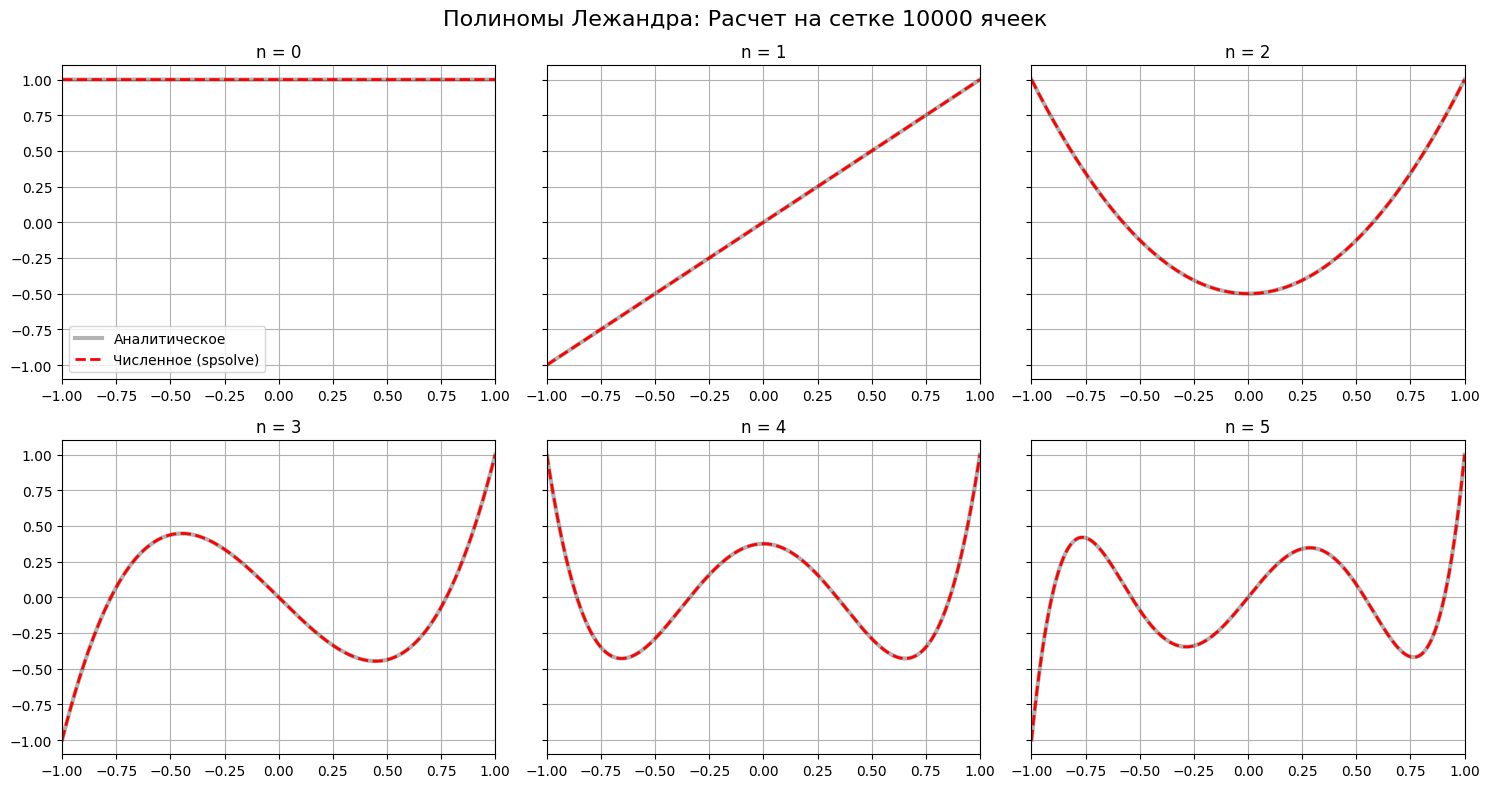

In [ ]:
shifts = [-0.1, 1.9, 5.9, 11.9, 19.9, 29.9]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()
fig.suptitle(f'Полиномы Лежандра: Расчет на сетке {N} ячеек', fontsize=16)

print(f"{'n':<2} | {'Точное λ':<10} | {'λ (spsolve)':<18} | {'λ (eigsh)':<15} | {'Погрешность функции':<20}")
print("-" * 80)

for n, shift in enumerate(shifts):
    eigval_num, eigvec_num = inverse_power_spsolve(A_sparse, shift)

    eigval_sh, eigvec_sh = eigsh(A_sparse, k=1, sigma=shift, which='LM')
    eigval_sh = eigval_sh[0]
    eigvec_sh = eigvec_sh[:, 0]

    eigvec = eigvec_num / np.max(np.abs(eigvec_num))
    if eigvec[-1] < 0:
        eigvec = -eigvec

    exact_eigval = n * (n + 1)
    y_exact = eval_legendre(n, xc)

    error = np.max(np.abs(eigvec - y_exact))

    print(f"{n:<2} | {exact_eigval:<10} | {eigval_num:<18.6f} | {eigval_sh:<15.6f} | {error:.2e}")

    ax = axes[n]
    ax.plot(xc, y_exact, 'k-', linewidth=3, alpha=0.3, label='Аналитическое')
    ax.plot(xc, eigvec, 'r--', linewidth=2, label='Численное (spsolve)')
    ax.set_title(f'n = {n}')
    ax.set_xlim(-1, 1)
    ax.grid(True)
    if n == 0:
        ax.legend()

plt.tight_layout()
plt.show()